# 90 – Sivupolut: epäviralliset tilastot blogiin

**Tehtävä:** kevennyksiä blogia varten. Muistio ei ole osa pääanalyysia, eikä sen tuloksia käytetä raportin johtopäätöksissä.

**Syöte:**
- `Data/processed/speeches_clean.parquet` (muistio 02) ja `speeches_raw.parquet` (muistio 01). Raakapuheet eivät ole repossa, joten muistio vaatii koko aineiston rakentamisen.
- `results/party_summary.csv` ja `party_confusion.json` (muistio 05) sekä `leaveout_party_pairs_year.csv` (muistio 06)

**Tulokset:** vain muistioon; tiedostoja ei tallenneta. Ajoaika noin minuutti.

Kaikki tulokset raportoidaan puoluetasolla. Välihuutojen tekijät tunnistetaan nimistä vain puolueen päättelemiseksi; nimiä ei tulosteta eikä edustajia aseteta järjestykseen.

Sisältö:
1. Kertooko sana *polarisaatio* polarisaatiosta?
2. Istuntosalin tunnelma: välihuudot, nauru, hälinä ja puhemiehen koputukset
3. Yöistunnot ja päivän rytmi
4. Vuoden sana
5. Sanonnat ja kielikuvat
6. Kuka puhuu kenestä?
7. Kysymys- ja huutomerkit
8. Tunnistettavin puolue
9. Mitä blogiin?

## 1. Kertooko sana *polarisaatio* polarisaatiosta?

Kun kansanedustajat puhuvat enemmän polarisaatiosta, ovatko puolueet myös kielellisesti erottuvampia? Verrataan sanan esiintyvyyttä kahteen päämittariin:

- luokittelijan erottuvuus kausittain (muistio 05)
- leave-out π vuosittain, 28 puolueparin keskiarvo (muistio 06)

Sanat haetaan vartaloiduista puheista (muistio 02). Mukaan otetaan kaikki vartalot, jotka alkavat *polaris*: substantiivi (*polarisaatio*, *polarisaatiokehitys*) ja verbi (*polarisoitua*, *polarisoida*). Esiintyvyys on osumia miljoonaa sanaa kohden. Sanoiksi lasketaan vartalot täytesanojen poiston jälkeen.

In [1]:
import re
import sys
import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, "../src")
import config

KANSIO = "../Data/processed/"
TULOKSET = "../results/"
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]

PUOLUEET = config.PARTY_ORDER          # 9 puoluetta, myös SIN
PAAPUOLUEET = config.MAIN_PARTIES      # 8 puoluetta, jotka ovat mukana kaikilla kausilla
pd.set_option("display.width", 200)

puheet = pd.read_parquet(KANSIO + "speeches_clean.parquet",
                         columns=["speech_id", "record_id", "term", "session_year", "party", "in_government",
                                  "person_id", "mp_name", "item_title", "start_time", "n_words_fi",
                                  "tokens", "n_tokens", "in_sample"])
puheet = puheet[puheet["in_sample"]].copy()
puheet["vuosi"] = puheet["session_year"].astype(int)
raaka = pd.read_parquet(KANSIO + "speeches_raw.parquet", columns=["speech_id", "text"])
puheet = puheet.merge(raaka, on="speech_id", how="left")

puheet["osumat"] = puheet["tokens"].str.count(r"(?:^| )polaris")
osumapuheet = puheet.loc[puheet["osumat"] > 0, "tokens"].str.split()
print("Puheita:", len(puheet), " osumia:", puheet["osumat"].sum(), " puheita, joissa osuma:", (puheet["osumat"] > 0).sum())

Puheita: 130965  osumia: 265  puheita, joissa osuma: 249


In [2]:
vartalot = Counter(w for ws in osumapuheet for w in ws if w.startswith("polaris"))
pd.Series(vartalot).sort_values(ascending=False).rename("osumia").to_frame()

,osumia
polarisaatio,128
polarisoitu,20
polarisoitun,19
polarisoitunu,19
polarisoitumin,12
polarisoi,10
polarisoitum,10
polarisoiv,9
polarisoitumis,9
polarisoituv,9


### Kausittain

Kaudella 2023–2027 on mukana vain vuodet 2023–2026, mutta esiintyvyys suhteutetaan sanamäärään, joten kaudet ovat vertailukelpoisia. Luottamusväli on karkea Poisson-arvio: osumien määrä ± 1,96·√osumat.

In [3]:
def esiintyvyys(taulu, ryhma):
    t = taulu.groupby(ryhma).agg(sanoja=("n_tokens", "sum"), osumia=("osumat", "sum"))
    t["per_milj"] = t["osumia"] / t["sanoja"] * 1e6
    virhe = 1.96 * t["osumia"] ** 0.5 / t["sanoja"] * 1e6
    t["ala"], t["yla"] = t["per_milj"] - virhe, t["per_milj"] + virhe
    return t

yhteenveto = pd.read_csv(TULOKSET + "party_summary.csv")
erottuvuus = yhteenveto[yhteenveto["series"] == "real"].groupby("term")["polarisation"].mean()

kausittain = esiintyvyys(puheet, "term")
kausittain["puhujia"] = puheet[puheet["osumat"] > 0].groupby("term")["person_id"].nunique()
kausittain["erottuvuus"] = erottuvuus
kausittain.round(3)

,sanoja,osumia,per_milj,ala,yla,puhujia,erottuvuus
term,,,,,,,
2015-2019,6826065,53,7.764,5.674,9.855,33,0.391
2019-2023,7039052,76,10.797,8.369,13.224,43,0.451
2023-2027,6277287,136,21.665,18.024,25.307,71,0.558


Sanan esiintyvyys lähes kolminkertaistuu, noin 8 → 11 → 22 osumaa miljoonaa sanaa kohden. Erottuvuus nousee 0,39 → 0,45 → 0,56. Suunta on sama, ja kummassakin suurin hyppy tulee kaudella 2023–2027. Kolmella havainnolla ei kuitenkaan voi laskea mielekästä korrelaatiota. Käyttäjien määrä kasvaa samaa tahtia (33 → 43 → 71 edustajaa), joten nousu ei johdu muutamasta ahkerasta puhujasta.

### Vuosittain

Vuositasolla havaintoja on 12, joten vertailukohtana on leave-out π. Vaalivuosina 2015, 2019 ja 2023 puheita on vähemmän, joten niiden arviot ovat epävarmempia. Korrelaatioksi valitaan Spearmanin järjestyskorrelaatio, koska se ei oleta lineaarista yhteyttä.

In [4]:
leaveout = pd.read_csv(TULOKSET + "leaveout_party_pairs_year.csv").groupby("year")["pi"].mean()
vuosittain = esiintyvyys(puheet, "vuosi")
vuosittain["pi"] = leaveout

r, p = spearmanr(vuosittain["per_milj"], vuosittain["pi"])
print(f"Tasot:     Spearman r = {r:.2f}, p = {p:.3f}")
muutos = vuosittain[["per_milj", "pi"]].diff().dropna()
r2, p2 = spearmanr(muutos["per_milj"], muutos["pi"])
print(f"Muutokset: Spearman r = {r2:.2f}, p = {p2:.3f}")
vuosittain[["sanoja", "osumia", "per_milj", "pi"]].round(4)

Tasot:     Spearman r = 0.71, p = 0.010
Muutokset: Spearman r = 0.20, p = 0.555


,sanoja,osumia,per_milj,pi
vuosi,,,,
2015,1085247,1,0.9214,0.5157
2016,1793408,8,4.4608,0.5184
2017,1776609,17,9.5688,0.5167
2018,2170801,27,12.4378,0.5135
2019,1047451,8,7.6376,0.5175
2020,1933675,15,7.7572,0.5195
2021,1922609,27,14.0434,0.5214
2022,2135317,26,12.1762,0.5166
2023,1039259,30,28.8667,0.5248


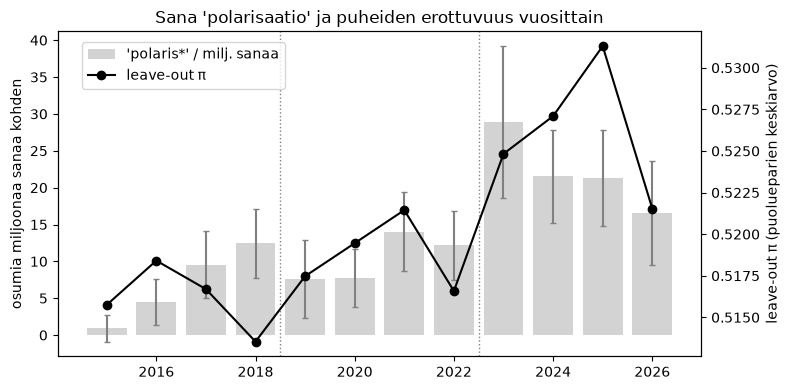

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vuosittain.index, vuosittain["per_milj"], color="lightgrey", label="'polaris*' / milj. sanaa")
ax.errorbar(vuosittain.index, vuosittain["per_milj"],
            yerr=[vuosittain["per_milj"] - vuosittain["ala"], vuosittain["yla"] - vuosittain["per_milj"]],
            fmt="none", ecolor="grey", capsize=2)
ax.set_ylabel("osumia miljoonaa sanaa kohden")
ax2 = ax.twinx()
ax2.plot(vuosittain.index, vuosittain["pi"], color="black", marker="o", label="leave-out π")
ax2.set_ylabel("leave-out π (puolueparien keskiarvo)")
for alku in [2019, 2023]:
    ax.axvline(alku - 0.5, color="grey", linestyle=":", linewidth=1)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
ax.set_title("Sana 'polarisaatio' ja puheiden erottuvuus vuosittain")
plt.tight_layout()
plt.show()

Vuositasoilla korrelaatio on melko vahva, r ≈ 0,7. Osa siitä johtuu kuitenkin siitä, että molemmat sarjat kasvavat ajan myötä. Kun verrataan vuosimuutoksia, yhteys käytännössä katoaa. Sana ei siis ennusta vuodesta toiseen, milloin puheet erottuvat, vaan molemmat kasvavat samassa pitkässä trendissä. Sanan yleistyminen voi johtua myös julkisesta keskustelusta ylipäätään, eikä vain eduskunnan omasta kehityksestä.

### Kuka polarisaatiosta puhuu?

Tarkastelu tehdään vain puoluetasolla.

In [6]:
puolueittain = esiintyvyys(puheet, "party").reindex(config.PARTY_ORDER)
puolueittain[["sanoja", "osumia", "per_milj"]].round(1)

,sanoja,osumia,per_milj
party,,,
VAS,1384194,36,26.0
SDP,4494079,77,17.1
VIHR,1657947,35,21.1
KESK,3656106,29,7.9
RKP,255118,7,27.4
KD,765347,9,11.8
KOK,3686438,36,9.8
SIN,244893,3,12.3
PS,3998282,33,8.3


In [7]:
puheet["asema"] = puheet["in_government"].map({True: "hallitus", False: "oppositio"})
asema = esiintyvyys(puheet, ["term", "asema"])["per_milj"].unstack()
asema.round(1)

asema,hallitus,oppositio
term,,
2015-2019,7.4,8.1
2019-2023,15.7,5.2
2023-2027,17.8,24.9


Polarisaatiosta puhuvat eniten vasemmistoliitto, vihreät ja SDP. RKP:n luku perustuu vain seitsemään osumaan, ja myös SIN:n ja KD:n osumamäärät ovat pieniä.

Sana ei ole pelkkää opposition retoriikkaa. Kaudella 2019–2023 hallitus käytti sitä noin kolme kertaa oppositiota useammin (16 vs. 5 osumaa miljoonaa sanaa kohden), ja silloin hallituksessa istuivat vasemmistoliitto, vihreät ja SDP. Kaudella 2023–2027 samat puolueet ovat oppositiossa, ja nyt oppositio käyttää sanaa enemmän (25 vs. 18). Sana seuraa siis puolueita eikä hallitusasemaa. Nousu näkyy tällä kaudella kuitenkin myös hallituspuolueilla.

### Missä yhteydessä?

Yleisimmät sanat enintään kolmen sanan päässä osumasta:

In [8]:
naapurit = Counter()
for ws in osumapuheet:
    for i, w in enumerate(ws):
        if w.startswith("polaris"):
            naapurit.update(x for x in ws[max(0, i - 3):i + 4] if not x.startswith("polaris") and x != "|")
pd.Series(naapurit).sort_values(ascending=False).head(20).rename("kertaa").to_frame()

,kertaa
yhteiskun,44
keskustelu,23
hyv,19
myös,16
nuort,16
ongelm,15
lisä,14
täl,11
aika,10
eli,9


Useimmiten puhutaan yhteiskunnan polarisaatiosta ja keskustelun polarisoitumisesta, usein myös nuorten yhteydessä. Seassa on myös muita merkityksiä, kuten työmarkkinoiden polarisaatio ja eriarvoisuus, joilla ei ole tekemistä puolueiden erottuvuuden kanssa. Sana mittaa siis puhetta polarisaatiosta, ei polarisaatiota itseään.

**Yhteenveto blogiin:** kun puolueiden puheet ovat erottuneet toisistaan, eduskunnassa on myös puhuttu polarisaatiosta yhä enemmän, noin kolme kertaa useammin kaudella 2023–2027 kuin 2015–2019. Sana seuraa pitkää trendiä, mutta ei vuosittaisia vaihteluita. Osumia on koko aineistossa vain 265, joten tämä on kevennys, ei mittari.

## 2. Istuntosalin tunnelma

Pöytäkirjoihin merkitään hakasulkeisiin tai sulkeisiin, mitä salissa tapahtuu puheen aikana, esimerkiksi *[Naurua]*, *[Välihuutoja vasemmalta]*, *[Perussuomalaisten ryhmästä: Oijoi!]* ja *[Puhemies koputtaa]*. Muistio 02 poistaa nämä analyysista, joten ne luetaan tässä raakateksteistä.

Merkinnät luokitellaan viiteen lajiin:

| laji | esimerkki |
|---|---|
| välihuuto | *[Nimi: Höpö höpö!]*, *[Nimen välihuuto]*, *[Välihuutoja vasemmalta]*, *[Keskustan ryhmästä: Kyllä!]*, *[Eduskunnasta: …]* |
| koputus | *[Puhemies koputtaa]*, yleensä merkki puheajan täyttymisestä |
| aika | *[Puhemies: Aika!]*, *[Puhemies: Aika on täynnä!]* |
| naurua | *[Naurua]* |
| hälinää | *[Hälinää]* |

Välihuudon tekijän puolue päätellään kolmella tavalla: huutajan nimestä saman kauden edustajaluettelon avulla, ryhmän nimestä (*Keskustan ryhmästä*) tai jättämällä se tuntemattomaksi (*Välihuutoja*, *Eduskunnasta*). Genetiivimuodot (*Kimmo Kivelän välihuuto*) tunnistetaan etunimen ja sukunimen alun perusteella, joten osa jää tunnistamatta.

**Varaus:** merkintäkäytäntö on pöytäkirjan laatijan valinta ja voi muuttua ajan myötä. Kausien väliset erot voivat siksi kertoa osin kirjauskäytännöstä.

In [9]:
SULKEET = re.compile(r"\[([^\]]+)\]|\(([^)]+)\)")

def merkinnat(teksti):
    """Sulkeiden sisällöt osiin pilkottuna: '[A: x — B: y]' -> ['A: x', 'B: y']."""
    osat = []
    for m in SULKEET.finditer(teksti or ""):
        osat += [o.strip() for o in re.split(r"\s+[—–-]\s+", m.group(1) or m.group(2))]
    return osat

nimet = puheet.groupby(["term", "mp_name"])["party"].agg(lambda x: x.mode().iat[0])
NIMET = {kausi: dict(taulu.droplevel(0)) for kausi, taulu in nimet.groupby(level=0)}
RYHMAT = {"perussuomalai": "PS", "sosiaalidemokraat": "SDP", "sosialidemokraat": "SDP", "keskustan": "KESK",
          "kokoomuksen": "KOK", "vihreiden": "VIHR", "vihreän": "VIHR", "vasemmistoliiton": "VAS",
          "kristillisdemokraat": "KD", "ruotsalaisen": "RKP", "sinisen": "SIN", "sinisten": "SIN"}


def laji(osa):
    o = osa.lower()
    if "koputtaa" in o:
        return "koputus"
    if o.startswith("puhemies"):
        return "aika" if "aika" in o else None
    if o.startswith("naurua"):
        return "naurua"
    if o.startswith("hälinää"):
        return "hälinää"
    if o.startswith("välihuu") or o.endswith("välihuuto") or re.match(r"^(eduskunnasta|vasemmalta|oikealta|keskeltä|[\w-]+ ryhmästä)", o):
        return "välihuuto"
    if ":" in osa and len(osa.split(":")[0].split()) in (2, 3):
        return "nimi"          # 'Etunimi Sukunimi: ...', tarkistetaan edustajaluettelosta
    return None


def huutajan_puolue(osa, kausi):
    o = osa.lower()
    if "ryhmästä" in o:
        return next((p for avain, p in RYHMAT.items() if avain in o), "?")
    if ":" in osa:
        return NIMET[kausi].get(osa.split(":")[0].strip())
    if o.endswith("välihuuto") and not o.startswith("välihuuto"):
        genetiivi = osa[:-len("välihuuto")].strip().rstrip("n").replace("’", "")
        for nimi, puolue in NIMET[kausi].items():
            etu, _, suku = nimi.partition(" ")
            if genetiivi.startswith(etu + " ") and len(suku) > 3 and genetiivi[len(etu) + 1:].startswith(suku[:-3]):
                return puolue
        return "?"
    if "vasemmalta" in o:
        return "vasemmalta"
    if "oikealta" in o:
        return "oikealta"
    return "?"


rivit = []
for puhe, puolue, kausi, vuosi, teksti in zip(puheet["speech_id"], puheet["party"], puheet["term"], puheet["vuosi"], puheet["text"]):
    for osa in merkinnat(teksti):
        l = laji(osa)
        huutaja = None
        if l == "nimi":
            huutaja = huutajan_puolue(osa, kausi)
            l = "välihuuto" if huutaja else None
        elif l == "välihuuto":
            huutaja = huutajan_puolue(osa, kausi)
        if l:
            rivit.append((puhe, puolue, kausi, vuosi, l, huutaja))
tapahtumat = pd.DataFrame(rivit, columns=["speech_id", "party", "term", "vuosi", "laji", "huutaja"])

LAJIT = ["välihuuto", "koputus", "aika", "naurua", "hälinää"]
maarat = tapahtumat.pivot_table(index="speech_id", columns="laji", aggfunc="size", fill_value=0)
for l in LAJIT:
    puheet[l] = puheet["speech_id"].map(maarat[l]).fillna(0)
tapahtumat["laji"].value_counts()

laji
välihuuto    53847
koputus      34602
aika          3967
naurua        2092
hälinää       1561
Name: count, dtype: int64

### Tapahtumat puolueittain ja kausittain

Luvut ovat tapahtumia sataa puhetta kohden. Taulukossa puolue on se puolue, jonka edustaja puhuu, eli esimerkiksi välihuudot ovat huutoja, jotka kohdistuvat puolueen puhujiin.

In [10]:
(puheet.groupby("party")[LAJIT].mean() * 100).reindex(PUOLUEET).round(1)

,välihuuto,koputus,aika,naurua,hälinää
party,,,,,
VAS,39.0,25.3,3.2,1.6,1.0
SDP,38.8,30.1,3.6,1.4,1.0
VIHR,31.3,27.3,2.9,0.6,0.9
KESK,39.9,25.4,2.2,2.1,1.1
RKP,30.5,31.6,4.6,1.4,0.6
KD,28.7,29.1,3.4,1.0,1.3
KOK,48.8,28.3,3.8,1.8,1.5
SIN,43.0,23.0,2.3,3.3,1.1
PS,45.9,20.6,2.1,1.6,1.5


In [11]:
(puheet.groupby("term")[LAJIT].mean() * 100).round(1)

,välihuuto,koputus,aika,naurua,hälinää
term,,,,,
2015-2019,28.1,26.8,2.9,1.7,1.1
2019-2023,43.2,28.4,4.3,1.4,1.0
2023-2027,55.8,23.6,1.8,1.6,1.5


Välihuudot kaksinkertaistuvat kauden 2015–19 noin 28:sta kauden 2023–27 noin 56:een sataa puhetta kohden. Eniten huutoja saavat kokoomuksen ja perussuomalaisten puhujat, vähiten kristillisdemokraattien, RKP:n ja vihreiden. Naurua kuuluu keskimäärin alle kahdesti sataa puhetta kohden. Suurin naurulukema on pienellä SIN-ryhmällä, joten se perustuu harvoihin puheisiin.

### Kuka huutaa kenelle?

Taulukossa rivi on huutajan puolue ja sarake puhujan puolue. Luku on **yliedustus**: huutajan välihuutojen osuus kyseisen puolueen puhujille jaettuna kyseisen puolueen osuudella kaikista puheista. Arvo 1 tarkoittaa, että puolueen puhujat saavat huutoja samassa suhteessa kuin puhuvat; arvo 2 tarkoittaa kaksinkertaista määrää. Mukana ovat kahdeksan pääpuoluetta ja välihuudot, joiden huutajan puolue tunnistettiin.

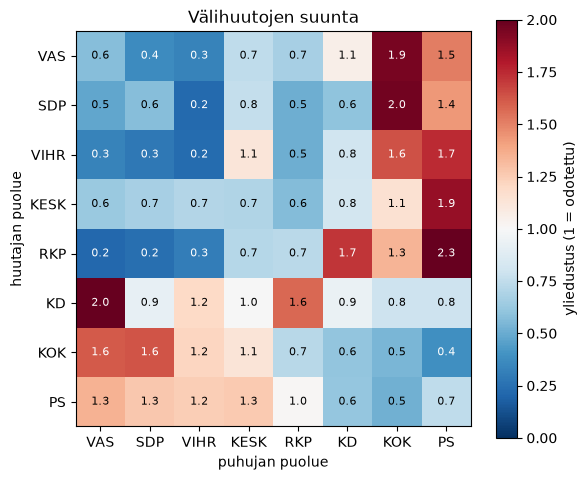

In [12]:
valihuudot = tapahtumat[(tapahtumat["laji"] == "välihuuto") & tapahtumat["huutaja"].isin(PAAPUOLUEET)
                        & tapahtumat["party"].isin(PAAPUOLUEET)]
ristiin = pd.crosstab(valihuudot["huutaja"], valihuudot["party"]).reindex(index=PAAPUOLUEET, columns=PAAPUOLUEET)
puheosuus = puheet["party"].value_counts(normalize=True).reindex(PAAPUOLUEET)
puheosuus = puheosuus / puheosuus.sum()
yliedustus = ristiin.div(ristiin.sum(axis=1), axis=0) / puheosuus

fig, ax = plt.subplots(figsize=(6, 5))
kuva = ax.imshow(yliedustus, cmap="RdBu_r", vmin=0, vmax=2)
ax.set_xticks(range(8), PAAPUOLUEET)
ax.set_yticks(range(8), PAAPUOLUEET)
ax.set_xlabel("puhujan puolue")
ax.set_ylabel("huutajan puolue")
for i in range(8):
    for j in range(8):
        arvo = yliedustus.iat[i, j]
        ax.text(j, i, f"{arvo:.1f}", ha="center", va="center", fontsize=8, color="white" if abs(arvo - 1) > 0.6 else "black")
fig.colorbar(kuva, label="yliedustus (1 = odotettu)")
ax.set_title("Välihuutojen suunta")
plt.tight_layout()
plt.show()

In [13]:
huutoja = pd.DataFrame({
    "välihuutoja": ristiin.sum(axis=1),
    "sataa omaa puhetta kohden": ristiin.sum(axis=1) / puheet["party"].value_counts().reindex(PAAPUOLUEET) * 100,
    "oman ryhmän puhujille (%)": np.diag(ristiin) / ristiin.sum(axis=1) * 100,
})
huutoja.round(1)

,välihuutoja,sataa omaa puhetta kohden,oman ryhmän puhujille (%)
huutaja,,,
VAS,3277,35.1,4.2
SDP,10734,37.4,12.8
VIHR,916,8.9,1.9
KESK,5401,22.5,13.0
RKP,575,20.7,1.6
KD,325,6.3,3.7
KOK,8770,36.5,10.1
PS,12482,49.7,14.5


Välihuudoissa näkyvät samat kaksi blokkia kuin puheiden erottuvuudessa. Vasemmistoliitto, SDP ja vihreät huutavat eniten kokoomuksen ja perussuomalaisten puhujille, ja kokoomus sekä perussuomalaiset huutavat eniten vasemmiston puhujille. Keskusta huutaa eniten perussuomalaisille. Kristillisdemokraattien huudot kohdistuvat eniten vasemmistoliittoon.

Omia sataa puhetta kohden eniten huutavat perussuomalaiset, SDP, kokoomus ja vasemmistoliitto. Vihreät ja kristillisdemokraatit huutavat vähiten. Osa huudoista on kannustusta omille: noin joka kymmenes SDP:n, keskustan, kokoomuksen ja perussuomalaisten huuto kohdistuu oman ryhmän puhujalle.

**Pienet määrät:** vihreiltä, RKP:ltä ja kristillisdemokraateilta on tunnistettu kultakin alle tuhat välihuutoa. Niiden rivit lämpökartassa ovat epävarmoja; esimerkiksi RKP:n perussuomalaisiin kohdistuva yliedustus (2,3) perustuu vain muutamaan sataan huutoon.

### Liittyykö hälinä polarisaatioon?

In [14]:
leaveout = pd.read_csv(TULOKSET + "leaveout_party_pairs_year.csv").groupby("year")["pi"].mean()
tunnelma = puheet.groupby("vuosi")[LAJIT].mean() * 100
tunnelma["pi"] = leaveout
tulos = []
for l in LAJIT:
    tasot = spearmanr(tunnelma[l], tunnelma["pi"])
    muutokset = spearmanr(tunnelma[l].diff().dropna(), tunnelma["pi"].diff().dropna())
    tulos.append({"laji": l, "r (tasot)": tasot.statistic, "p (tasot)": tasot.pvalue, "r (muutokset)": muutokset.statistic})
display(pd.DataFrame(tulos).set_index("laji").round(2))
tunnelma.round(2)

,r (tasot),p (tasot),r (muutokset)
laji,,,
välihuuto,0.63,0.03,0.23
koputus,-0.06,0.85,0.38
aika,-0.14,0.66,0.16
naurua,-0.13,0.70,0.48
hälinää,0.35,0.27,0.54


,välihuuto,koputus,aika,naurua,hälinää,pi
vuosi,,,,,,
2015,26.91,28.41,3.99,2.00,1.54,0.52
2016,22.21,25.22,1.61,1.77,1.39,0.52
2017,32.39,30.99,0.51,1.79,1.17,0.52
2018,30.33,23.66,5.55,1.48,0.66,0.51
2019,62.16,29.46,5.21,1.89,1.64,0.52
2020,34.38,32.82,6.37,1.26,0.73,0.52
2021,39.84,32.92,4.53,1.36,0.76,0.52
2022,44.70,19.34,1.51,1.45,1.09,0.52
2023,71.67,25.07,1.66,2.10,1.71,0.52


Välihuutojen määrä korreloi leave-out π:n kanssa vuositasolla (r ≈ 0,6), mutta muutoksissa yhteys on heikko, kuten polarisaatio-sanallakin. Taulukossa on viisi testiä, joten p = 0,03 on rajatapaus: jos merkitsevyystaso korjataan testien määrällä (Bonferroni, 0,05 / 5 = 0,01), yksikään yhteys ei ole merkitsevä. Kaksitoista vuotta on lisäksi pieni otos. Koputus, hälinä ja nauru eivät seuraa polarisaatiota tilastollisesti merkitsevästi. Välihuutoja on eniten vaalivuosina 2019 ja 2023, jolloin kevään istunnot ovat vaalikampanjan aikaa.

## 3. Yöistunnot ja päivän rytmi

Kellonaika on puheenvuoron alkamisaika Suomen aikaa. Yöpuheeksi lasketaan klo 22.00–07.59 alkanut puheenvuoro.

In [15]:
aika = puheet["start_time"].dt.tz_convert("Europe/Helsinki")
puheet["tunti"] = aika.dt.hour
puheet["yö"] = (puheet["tunti"] >= 22) | (puheet["tunti"] < 8)
# minuutit istuntopäivän alusta; puolenyön jälkeiset puheet jatkavat edellistä päivää
puheet["minuutti"] = (puheet["tunti"] + 24 * (puheet["tunti"] < 8)) * 60 + aika.dt.minute
puheet["pvm"] = aika.dt.date

print(f"Yöpuheita {puheet['yö'].sum()} ({puheet['yö'].mean():.1%} kaikista)")
pd.DataFrame({
    "yöpuheita": puheet.groupby("party")["yö"].sum(),
    "osuus puolueen puheista (%)": puheet.groupby("party")["yö"].mean() * 100,
}).reindex(PUOLUEET).round(1)

Yöpuheita 3691 (2.8% kaikista)


,yöpuheita,osuus puolueen puheista (%)
party,,
VAS,241,2.6
SDP,971,3.4
VIHR,342,3.3
KESK,691,2.9
RKP,43,1.5
KD,138,2.7
KOK,526,2.2
SIN,15,0.9
PS,724,2.9


In [16]:
istunnot = puheet.groupby("record_id").agg(
    pvm=("pvm", "min"), viimeinen=("minuutti", "max"), puheita=("speech_id", "size"),
    yleisin_asia=("item_title", lambda x: x.value_counts().index[0][:90]))
istunnot["päättyi"] = istunnot["viimeinen"].map(lambda m: f"{(m // 60) % 24:02d}.{m % 60:02d}")
istunnot.sort_values("viimeinen", ascending=False).head(8)[["pvm", "päättyi", "puheita", "yleisin_asia"]]

,pvm,päättyi,puheita,yleisin_asia
record_id,,,,
PTK 57/2021 vp,2021-05-12,07.57,275,Hallituksen esitys eduskunnalle Euroopan uni...
PTK 55/2021 vp,2021-05-11,04.18,233,Hallituksen esitys eduskunnalle Euroopan unio...
PTK 131/2016 vp,2016-12-13,04.16,120,Hallituksen esitys eduskunnalle laeiksi opin...
PTK 77/2015 vp,2015-12-08,04.08,409,Hallituksen esitys eduskunnalle laeiksi varhai...
PTK 144/2017 vp,2017-12-18,04.00,463,Pääluokka 29 Opetus- ja kulttuuriministeriön h...
PTK 84/2019 vp,2019-12-17,03.51,358,Hallituksen esitys eduskunnalle vuoden 2020 ta...
PTK 140/2017 vp,2017-12-14,03.46,138,Hallituksen esitys eduskunnalle alkoholilaiksi...
PTK 79/2015 vp,2015-12-10,03.06,360,Hallituksen esitys eduskunnalle laeiksi yliopi...


In [17]:
pisin = istunnot["viimeinen"].idxmax()
print("Pisimmän istunnon yöpuheet puolueittain (%):")
(puheet[(puheet["record_id"] == pisin) & puheet["yö"]]["party"].value_counts(normalize=True) * 100).round(0)

Pisimmän istunnon yöpuheet puolueittain (%):


party
PS      99.0
KESK     1.0
Name: proportion, dtype: float64

In [18]:
puheet[puheet["yö"]]["item_title"].str[:100].value_counts().head(8)

item_title
Hallituksen esitys  eduskunnalle  Euroopan unionin  omien varojen järjestelmästä annetun neuvoston p    141
Hallituksen esitys eduskunnalle alkoholilaiksi ja eräiksi siihen liittyviksi laeiksi                    116
Välikysymys hallituksen lisäleikkauksista soteen ja koulutukseen                                        113
Pääluokka 31 Liikenne- ja viestintäministeriön hallinnonala                                              76
Hallituksen esitys eduskunnalle valtion talousarvioksi vuodelle 2024                                     69
Pääluokka 30 Maa- ja metsätalousministeriön hallinnonala                                                 68
Hallituksen esitys eduskunnalle laeiksi työehtosopimuslain ja työriitojen sovittelusta annetun lain      61
Hallituksen esitys eduskunnalle  Euroopan unionin omien  varojen  järjestelmästä annetun neuvoston p     57
Name: count, dtype: int64

In [19]:
puheet["vaihe"] = pd.cut(puheet["tunti"] + 24 * (puheet["tunti"] < 8), [7, 13, 17, 21, 32],
                         labels=["aamupäivä (8–13)", "iltapäivä (14–17)", "ilta (18–21)", "yö (22–7)"])
rytmi = puheet.groupby("vaihe", observed=True).agg(puheita=("speech_id", "size"), sanoja_mediaani=("n_words_fi", "median"))
rytmi = rytmi.join(puheet.groupby("vaihe", observed=True)[["välihuuto", "naurua", "koputus"]].mean() * 100)
rytmi.round(1)

,puheita,sanoja_mediaani,välihuuto,naurua,koputus
vaihe,,,,,
aamupäivä (8–13),11455,132.0,50.9,2.2,32.1
iltapäivä (14–17),86398,137.0,45.2,1.7,29.1
ilta (18–21),29421,238.0,26.6,1.0,17.5
yö (22–7),3691,241.0,29.8,1.8,16.6


Pisin istunto alkoi 12.5.2021 ja päättyi seuraavana aamuna vähän ennen kahdeksaa. Asiana oli EU:n omien varojen järjestelmä eli elpymispaketti. Yön puheenvuoroista valtaosa oli perussuomalaisten. Muut pitkät yöt osuvat joulukuun budjettikäsittelyihin ja suuriin lakiesityksiin, kuten alkoholilakiin.

Iltaa ja yötä kohden puheet pitenevät (mediaani noin 135 → 240 sanaa), ja välihuudot sekä koputukset vähenevät. Todennäköinen syy on, että illalla pidetään pitkiä varsinaisia puheenvuoroja ja salissa on vähemmän kuulijoita.

## 4. Vuoden sana

Mikä sana yleistyi eniten edelliseen vuoteen verrattuna? Pisteet ovat log-suhde: log((n_vuosi + 5) / N_vuosi) − log((n_edellinen + 5) / N_edellinen), jossa *n* on sanan esiintymät ja *N* kaikki sanat. Lisäys 5 estää harvinaisia sanoja nousemasta kärkeen. Mukaan otetaan vartalot, joita on käytetty vuoden aikana vähintään 50 kertaa ja joita on käyttänyt vähintään 15 eri edustajaa. Puolueiden nimet jätetään pois, koska niiden kirjoitusasu vaihtelee.

Vuosi 2015 jätetään pois, koska vertailuvuotta ei ole. Vuosi 2026 on vajaa.

In [20]:
sanat_vuosi = defaultdict(Counter)
puhujat_vuosi = defaultdict(Counter)
for (vuosi, _), tokenit in puheet.groupby(["vuosi", "person_id"])["tokens"]:
    sanalista = [w for t in tokenit for w in t.split() if w != "|"]
    sanat_vuosi[vuosi].update(sanalista)
    puhujat_vuosi[vuosi].update(set(sanalista))
koko = {v: sum(c.values()) for v, c in sanat_vuosi.items()}
PUOLUENIMET = re.compile(r"^(sosiaa?lidemokraat|sosialidemokraat|kokoomu|perussuomalai|vasemmistoliit|vihre|keskust|kristillisdemokraat|rkp)")

vuoden_sanat = []
for vuosi in range(2016, 2027):
    nyt, ennen = sanat_vuosi[vuosi], sanat_vuosi[vuosi - 1]
    pisteet = {w: np.log((n + 5) / koko[vuosi]) - np.log((ennen[w] + 5) / koko[vuosi - 1])
               for w, n in nyt.items()
               if n >= 50 and puhujat_vuosi[vuosi][w] >= 15 and not PUOLUENIMET.match(w)}
    kärki = sorted(pisteet, key=pisteet.get, reverse=True)[:5]
    vuoden_sanat.append({"vuosi": vuosi, **{f"{i + 1}.": f"{w} ({ennen[w]} → {nyt[w]})" for i, w in enumerate(kärki)}})
pd.DataFrame(vuoden_sanat).set_index("vuosi")

,1.,2.,3.,4.,5.
vuosi,,,,,
2016,kilpailukykysopimuks (0 → 341),kiky (0 → 301),kilpailukykysopimus (0 → 235),taisteluosasto (0 → 207),kehitysyhtiö (0 → 164)
2017,saatavuusharkin (0 → 215),eutanasia (5 → 259),aktiivimal (9 → 352),etämyynt (2 → 163),ceta (1 → 134)
2018,osakesäästötil (0 → 201),oppimateriaalilis (0 → 164),kevytauto (0 → 153),sopeutumiseläk (1 → 180),lapsiasiainvaltuutetu (2 → 152)
2019,terapiataku (0 → 202),hol (1 → 159),työllisyystoim (15 → 435),norp (1 → 106),vappusatas (0 → 70)
2020,koron (0 → 1778),koronakriis (0 → 1071),valmiusl (0 → 735),epidemia (2 → 931),ravintolo (3 → 1034)
2021,koronapas (0 → 691),tapahtumataku (0 → 146),rokottamattom (0 → 141),rokotetu (7 → 334),rokotuks (14 → 441)
2022,hyökkäyssod (0 → 294),ukr (12 → 1010),hyökkäyso (0 → 265),ukrainalais (2 → 351),ukrain (57 → 2554)
2023,taisteluosasto (1 → 212),indeksijäädytyks (1 → 171),tiedonano (3 → 191),sofa (0 → 93),ensiasuno (8 → 238)
2024,sovittelij (1 → 237),palkkatas (0 → 140),päivystyks (14 → 528),yöpäivystyks (2 → 191),palkkaraj (1 → 157)


Lista kertoo vuosikymmenen tarinan: kilpailukykysopimus (*kiky*, 2016), aktiivimalli ja eutanasia (2017), osakesäästötili (2018), terapiatakuu ja vappusatanen (2019), korona (2020), koronapassi (2021), Ukrainan sota (2022), indeksijäädytys ja Naton SOFA-sopimus (2023), työriitojen sovittelija ja päivystykset (2024) sekä velkajarru (2025). Vuoden 2026 kärjessä on *gard*, joka tulee Helsinki Garden -areenasta. Mukana on myös vartaloinnin sivutuotteita, kuten *hol* ja *house* (*in-house*), joten lista kannattaa lukea harkiten.

## 5. Sanonnat ja kielikuvat

Haetaan raakateksteistä joukko tunnettuja sanontoja. Sulkeissa olevat merkinnät (välihuudot) poistetaan ensin. Hakulausekkeet sallivat taivutuksen vain osittain, joten luvut ovat alarajoja.

In [21]:
del sanat_vuosi, puhujat_vuosi
puheet["puhdas"] = puheet["text"].map(lambda t: SULKEET.sub(" ", t or "").lower())
puheet = puheet.drop(columns=["text", "tokens"])
SANONNAT = {
    "lehmänkauppa": r"lehmänkaup", "tyhjän päälle": r"tyhjän päälle", "jälkiviisaus": r"jälkiviisa",
    "ojasta allikkoon": r"ojasta allikkoon", "karhunpalvelus": r"karhunpalvelu", "rusinat pullasta": r"rusin\w* pullasta",
    "pelimerkit": r"pelimerk", "yhteinen sävel": r"yhteinen sävel|yhteisen sävelen", "kädestä suuhun": r"kädestä suuhun",
    "pää pensaassa": r"pää\w* pensaa(ssa|seen)", "Kankkulan kaivo": r"kankkulan kaivo", "sutta ja sekundaa": r"sutta ja sekundaa",
    "kissa pöydälle": r"kissa\w* pöydälle", "kuin kissa kuumaa puuroa": r"kuumaa puuroa", "puuta heinää": r"puuta heinää",
    "saappaat jalassa": r"saappaat jalassa", "kultalusikka suussa": r"kultalusik",
}
sanonnat = pd.DataFrame({k: puheet["puhdas"].str.count(p) for k, p in SANONNAT.items()})
display(sanonnat.sum().sort_values(ascending=False).rename("kertaa").to_frame().T)

sanoja_puolue = puheet.groupby("party")["n_words_fi"].sum()
pd.DataFrame({
    "sanontoja": sanonnat.groupby(puheet["party"]).sum().sum(axis=1),
    "miljoonaa sanaa kohden": sanonnat.groupby(puheet["party"]).sum().sum(axis=1) / sanoja_puolue * 1e6,
    "yleisin": sanonnat.groupby(puheet["party"]).sum().idxmax(axis=1),
}).reindex(PUOLUEET).round(1)

,lehmänkauppa,tyhjän päälle,jälkiviisaus,ojasta allikkoon,karhunpalvelus,rusinat pullasta,pelimerkit,yhteinen sävel,kädestä suuhun,Kankkulan kaivo,pää pensaassa,sutta ja sekundaa,kissa pöydälle,kuin kissa kuumaa puuroa,puuta heinää,saappaat jalassa,kultalusikka suussa
kertaa,122,121,113,81,77,76,73,71,67,51,45,36,28,17,11,8,3


,sanontoja,miljoonaa sanaa kohden,yleisin
party,,,
VAS,89,44.5,lehmänkauppa
SDP,248,37.2,lehmänkauppa
VIHR,109,46.2,tyhjän päälle
KESK,149,27.9,jälkiviisaus
RKP,24,62.1,lehmänkauppa
KD,40,35.9,karhunpalvelus
KOK,120,22.1,tyhjän päälle
SIN,15,42.4,jälkiviisaus
PS,206,35.6,jälkiviisaus


Eduskunnan suosikkisanonta on *lehmänkauppa*, ja lähes yhtä usein moititaan jonkin rakentuvan *tyhjän päälle* tai vedotaan *jälkiviisauteen*. Suhteessa puheen määrään sanontoja käyttävät eniten RKP, vihreät ja vasemmistoliitto, vähiten kokoomus ja keskusta. RKP:n suomenkielistä puhetta on vähän, joten sen luku on epävarmin.

## 6. Kuka puhuu kenestä?

Lasketaan, kuinka usein kunkin puolueen puhujat mainitsevat puolueita nimeltä (mainintoja 10 000 sanaa kohden). Hakulausekkeet ovat karkeita: *keskusta* voi tarkoittaa myös kaupungin keskustaa, ja *vihreät* myös vihreää siirtymää (siksi mukana ovat vain monikkomuodot). SDP:stä haetaan molemmat kirjoitusasut sekä *demarit*.

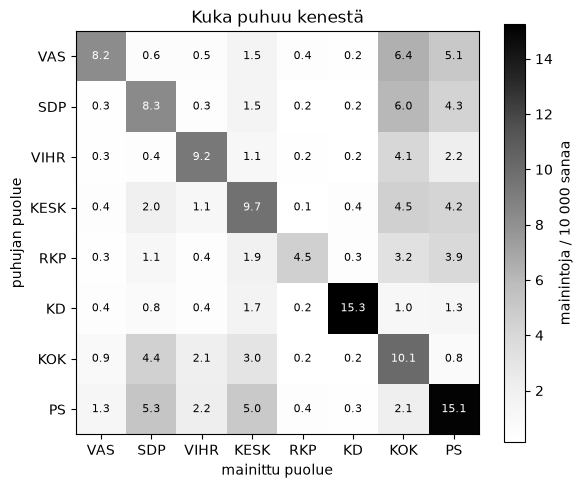

Mainintoja yhteensä: {'PS': 16196, 'KOK': 15615, 'SDP': 12531, 'KESK': 11497, 'VIHR': 5606, 'VAS': 3436, 'KD': 2366, 'RKP': 838}


In [22]:
MAININNAT = {
    "VAS": r"\bvasemmistoliit\w*",
    "SDP": r"\b(sdp\w*|demari\w*|sosiaa?lidemokraat\w*)",
    "VIHR": r"\b(vihre(ät|iden|ille|iltä|illä|itä|issä|isiin)\b|vihreä liitto\w*)",
    "KESK": r"\b(keskusta(n|a|lla|lta|lle)?\b|keskustala\w*)",
    "RKP": r"\b(rkp\w*|ruotsalai\w* kansanpuolue\w*)",
    "KD": r"\b(kristillisdemokraat\w*|kd\b|kd:\w*)",
    "KOK": r"\bkokoomu\w*",
    "PS": r"\bperussuomalai\w*",
}
maininnat = pd.DataFrame({k: puheet["puhdas"].str.count(p) for k, p in MAININNAT.items()})
per_sana = maininnat.groupby(puheet["party"]).sum().div(sanoja_puolue, axis=0).reindex(PAAPUOLUEET) * 1e4

fig, ax = plt.subplots(figsize=(6, 5))
kuva = ax.imshow(per_sana, cmap="Greys")
ax.set_xticks(range(8), PAAPUOLUEET)
ax.set_yticks(range(8), PAAPUOLUEET)
ax.set_xlabel("mainittu puolue")
ax.set_ylabel("puhujan puolue")
for i in range(8):
    for j in range(8):
        arvo = per_sana.iat[i, j]
        ax.text(j, i, f"{arvo:.1f}", ha="center", va="center", fontsize=8, color="white" if arvo > 8 else "black")
fig.colorbar(kuva, label="mainintoja / 10 000 sanaa")
ax.set_title("Kuka puhuu kenestä")
plt.tight_layout()
plt.show()
print("Mainintoja yhteensä:", maininnat.sum().sort_values(ascending=False).to_dict())

Jokainen puolue puhuu eniten itsestään; kristillisdemokraatit ja perussuomalaiset selvästi eniten. Muista puolueista vasemmistoliitto, SDP ja vihreät puhuvat eniten kokoomuksesta ja perussuomalaisista, kokoomus SDP:stä ja perussuomalaiset SDP:stä ja keskustasta. Kaikkiaan eniten mainitaan perussuomalaiset ja kokoomus. Asetelma on sama kuin välihuudoissa ja puheiden erottuvuudessa.

## 7. Kysymys- ja huutomerkit

Merkkejä 1 000 sanaa kohden (välihuudot poistettu). Välimerkit ovat osin pöytäkirjan kirjoittajan valintoja, joten erot kertovat puhetyylistä vain karkeasti.

In [23]:
valimerkit = pd.DataFrame({"kysymysmerkit": puheet["puhdas"].str.count(r"\?"), "huutomerkit": puheet["puhdas"].str.count("!")})
(valimerkit.groupby(puheet["party"]).sum().div(sanoja_puolue, axis=0) * 1000).reindex(PUOLUEET).round(2)

,kysymysmerkit,huutomerkit
party,,
VAS,2.89,7.07
SDP,2.60,5.83
VIHR,2.34,6.06
KESK,2.29,6.31
RKP,4.10,6.69
KD,2.77,5.77
KOK,2.46,6.23
SIN,1.92,6.11
PS,3.14,6.54


Eniten kysymyksiä esittävät RKP ja perussuomalaiset, eniten huudahduksia vasemmistoliitto. Erot ovat pieniä.

## 8. Tunnistettavin puolue

Luokittelijan sekaannusmatriisista (muistio 05) nähdään, kuinka usein kunkin puolueen puhe tunnistetaan oikein (*recall*) ja keneksi puolue useimmin luullaan. Arvaamalla oikein osuisi 1/8 = 12,5 % puheista.

In [24]:
sekaannus = json.load(open(TULOKSET + "party_confusion.json"))
taulu = {}
for kausi in KAUDET:
    m = pd.DataFrame(sekaannus[kausi]).loc[PAAPUOLUEET, PAAPUOLUEET]
    muut = m.where(~np.eye(8, dtype=bool))
    taulu[kausi] = [f"{m.at[p, p]:.0%} (luullaan: {muut.loc[p].idxmax()})" for p in PAAPUOLUEET]
pd.DataFrame(taulu, index=PAAPUOLUEET)

,2015-2019,2019-2023,2023-2027
VAS,15% (luullaan: SDP),20% (luullaan: SDP),44% (luullaan: VIHR)
SDP,24% (luullaan: VAS),25% (luullaan: KESK),27% (luullaan: KESK)
VIHR,28% (luullaan: VAS),43% (luullaan: VAS),38% (luullaan: VAS)
KESK,33% (luullaan: KOK),24% (luullaan: SDP),41% (luullaan: SDP)
RKP,33% (luullaan: VIHR),26% (luullaan: VIHR),35% (luullaan: KD)
KD,14% (luullaan: PS),14% (luullaan: KOK),18% (luullaan: KOK)
KOK,22% (luullaan: KESK),25% (luullaan: PS),26% (luullaan: PS)
PS,30% (luullaan: KESK),46% (luullaan: KOK),36% (luullaan: KOK)


Kaudella 2023–27 tunnistettavimmat ovat vasemmistoliitto (44 %) ja keskusta (41 %), kaudella 2019–23 perussuomalaiset (46 %) ja vihreät (43 %). Vaikeimmin tunnistettava on kristillisdemokraatit, joiden puheet menevät usein kokoomuksen tai perussuomalaisten nimiin. Sekaannukset noudattavat pääosin blokkeja: vasemmistoliitto, SDP ja vihreät sekoittuvat keskenään, samoin kokoomus, perussuomalaiset ja kristillisdemokraatit.

## 9. Mitä blogiin?

**Suosittelen nostettavaksi** (liittyvät pääkertomukseen ja ovat helppoja kuvittaa):

1. **Välihuutojen suunta** (kohta 2): lämpökartta näyttää samat kaksi blokkia kuin puheiden erottuvuus, mutta paljon konkreettisemmin. Tämä on vahvin kevennys, koska se tukee päätulosta.
2. **Polarisaatio-sana** (kohta 1): sanan käyttö on kolminkertaistunut samaan aikaan kuin puolueiden puheet ovat erkaantuneet.
3. **Vuoden sana** (kohta 4): aikajana *kiky* → *korona* → *Ukraina* → *velkajarru* kertoo lukijalle, mistä eduskunnassa on puhuttu. Sopii aineiston esittelyyn blogin alkuun.
4. **Pisin yö** (kohta 3): elpymispaketin istunto kesti aamukahdeksaan. Hyvä yhden virkkeen anekdootti.

**Sopii sivulauseeksi tai faktalaatikkoon:** eduskunnan suosikkisanonta *lehmänkauppa* (kohta 5), kuka puhuu kenestä (kohta 6) ja tunnistettavin puolue (kohta 8).

**Jättäisin pois:** välimerkit (kohta 7), koska erot ovat pieniä ja riippuvat kirjaajasta.

**Muista blogissa:** välihuutojen kirjauskäytäntö voi vaihdella, sanonta- ja mainintahaut ovat karkeita, ja yksikään näistä ei ole tutkimuksen mittari. Kaikki raportoidaan puoluetasolla.